In [1]:
import sys, os, importlib.util
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import lambda2nu, nu2lambda, c

from IPython.core.display import HTML
from IPython.core.pylabtools import figsize
from IPython.display import display, Math

HTML(""""
<style>
.output_png{
     display: table-cell;
     text-align: center;
     vertical-align: middle;
     }
</style>
""")

# Função para substituir importlib.load_source(nome, caminho)
def carregar_fonte(nome_modulo, caminho_arquivo):
    spec = importlib.util.spec_from_file_location(nome_modulo, caminho_arquivo)
    modulo = importlib.util.module_from_spec(spec)
    sys.modules[nome_modulo] = modulo
    spec.loader.exec_module(modulo)
    
    return modulo

#lumapiFile = "/opt/lumerical/v221/api/python/lumapi.py"
lumapiFile = "C:\\Program Files\\Lumerical\\v221\\api\\python\\lumapi.py"
lumapi = carregar_fonte("lumapi", lumapiFile)
modeApi = lumapi.MODE(hide = False)

C:\Program Files\Lumerical\v221\api\python\lumapi.py:796: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


Geometria

In [2]:
microns = 1e-6
wg_height = 0.22 *microns
wg_width = 0.45 *microns
wg_len = 3 * microns

In [3]:
modeApi.addrect()
modeApi.set("name", "waveguide")
modeApi.set("x", 0)
modeApi.set("y", 0)
modeApi.set("z", 0)
modeApi.set("x span", wg_width)
modeApi.set("y span", wg_height)
modeApi.set("z span", wg_len)
modeApi.set("material", "Si (Silicon) - Palik")

modeApi.addfde()
modeApi.set("solver type", 3)
modeApi.set("x", 0)
modeApi.set("y", 0)
modeApi.set("z", 0)
modeApi.set("x span", wg_width * 2)
modeApi.set("y span", wg_height * 2)
modeApi.set("background material", "SiO2 (Glass) - Palik")

modeApi.addmesh()
modeApi.set("x", 0)
modeApi.set("y", 0)
modeApi.set("z", 0)
modeApi.set("x span", wg_width * 1.5)
modeApi.set("y span", wg_height * 1.5)
modeApi.set("z span", 0)

Plotagem neff versus wco

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
num_modos = 6
vec_width = np.linspace(0.3 *microns, 1 *microns, 29)
matriz_modos = np.zeros((num_modos, len(vec_width), 2))

In [6]:
for i in range(len(vec_width)):
    modeApi.switchtolayout()
    modeApi.setnamed("waveguide", "x span", vec_width[i])
    modeApi.setnamed("FDE", "x span", vec_width[i] * 2)
    modeApi.setnamed("mesh", "x span", vec_width[i] * 1.5)
    modeApi.redraw()
    modeApi.findmodes()

    for j in range(0, num_modos):
        matriz_modos[j, i, 0] = modeApi.real(modeApi.getdata("mode" + modeApi.num2str(j+1), "neff"))
        matriz_modos[j, i, 1] = modeApi.getdata("mode" + modeApi.num2str(j+1), "TE polarization fraction")

<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
C:\Users\mariana.lima\AppData\Local\Temp\ipykernel_16472\3985296450.py:31: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Comprimento do guia ($\mu m$)')


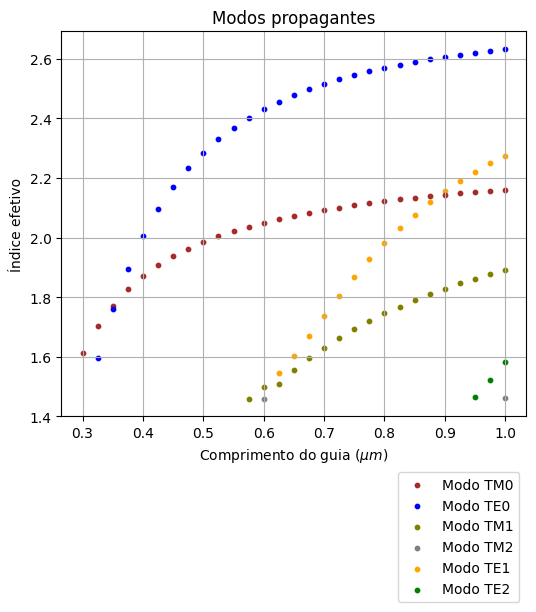

In [7]:
plt.figure(figsize=(6, 5))

lista_cores_TE = ["blue", "orange", "green", "red", "cyan", "yellow", "purple"]
lista_cores_TM = ["brown", "olive", "gray", "lightgreen", "pink", "sandybrown"]

contagemTE = -1
contagemTM = -1

for i in range(len(vec_width)):
    modoTE = -1
    modoTM = -1
    for j in range(0,num_modos):

        if (matriz_modos[j, i, 0]) > 1.44: # Condição que exige que o modo seja válido

            if (matriz_modos[j, i, 1] >= 0.5):
                modoTE = modoTE + 1
                if (contagemTE < modoTE):
                    plt.scatter(vec_width[i]/microns, matriz_modos[j, i, 0], color=lista_cores_TE[modoTE], s=10, label='Modo TE%g' % modoTE)
                    contagemTE = contagemTE + 1
                else:
                    plt.scatter(vec_width[i]/microns, matriz_modos[j, i, 0], color=lista_cores_TE[modoTE], s=10)
            else:
                modoTM = modoTM + 1
                if (contagemTM < modoTM):
                    plt.scatter(vec_width[i]/microns, matriz_modos[j, i, 0], color=lista_cores_TM[modoTM], s=10, label='Modo TM%g' % modoTM)
                    contagemTM = contagemTM + 1
                else:
                    plt.scatter(vec_width[i]/microns, matriz_modos[j, i, 0], color=lista_cores_TM[modoTM], s=10)

plt.xlabel('Comprimento do guia ($\mu m$)')
plt.ylabel('Índice efetivo')
plt.title('Modos propagantes')
plt.legend(bbox_to_anchor=(1, -0.5), loc='lower right')
plt.grid(True)

plt.show()

Algoritmo de otimização

In [20]:
num_modos = 3

vec_width1 = np.linspace(0.35 *microns, 0.45 *microns, 11)
vec_width2 = np.linspace(0.75 *microns, 0.85 *microns, 11)

matriz_modos1 = np.zeros((num_modos, len(vec_width1), 2))
matriz_modos2 = np.zeros((num_modos, len(vec_width2), 2))

modeApi.switchtolayout()
modeApi.setnamed("FDE", "x span", 2 *microns)
modeApi.setnamed("FDE", "y span", 2 *microns)

In [21]:
for w1 in range(len(vec_width1)):
    modeApi.switchtolayout()
    modeApi.setnamed("waveguide", "x span", vec_width1[w1])
    modeApi.setnamed("mesh", "x span", vec_width1[w1] * 1.5)
    modeApi.redraw()
    modeApi.findmodes()

    for j in range(0, num_modos):
        matriz_modos1[j, w1, 0] = modeApi.real(modeApi.getdata("mode" + modeApi.num2str(j+1), "neff"))
        matriz_modos1[j, w1, 1] = modeApi.getdata("mode" + modeApi.num2str(j+1), "TE polarization fraction")

<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
C:\Users\mariana.lima\AppData\Local\Temp\ipykernel_16472\3787271430.py:31: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Comprimento do guia ($\mu m$)')


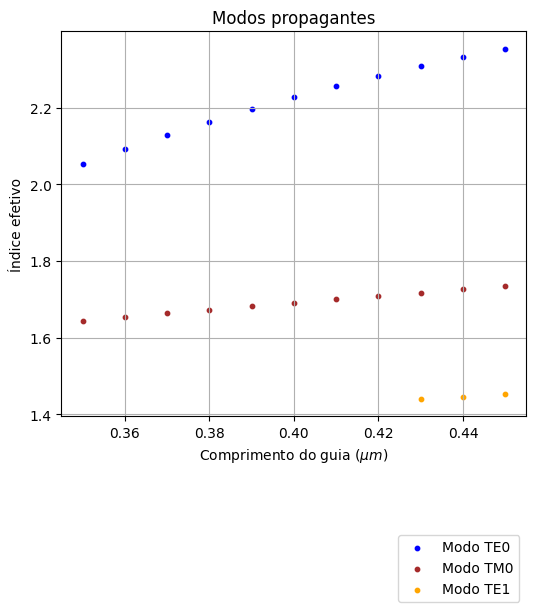

In [22]:
plt.figure(figsize=(6, 5))

lista_cores_TE = ["blue", "orange", "green", "red", "cyan", "yellow", "purple"]
lista_cores_TM = ["brown", "olive", "gray", "lightgreen", "pink", "sandybrown"]

contagemTE = -1
contagemTM = -1

for i in range(len(vec_width1)):
    modoTE = -1
    modoTM = -1
    for j in range(0,num_modos):

        if (matriz_modos1[j, i, 0]) > 1.44: # Condição que exige que o modo seja válido

            if (matriz_modos1[j, i, 1] >= 0.5):
                modoTE = modoTE + 1
                if (contagemTE < modoTE):
                    plt.scatter(vec_width1[i]/microns, matriz_modos1[j, i, 0], color=lista_cores_TE[modoTE], s=10, label='Modo TE%g' % modoTE)
                    contagemTE = contagemTE + 1
                else:
                    plt.scatter(vec_width1[i]/microns, matriz_modos1[j, i, 0], color=lista_cores_TE[modoTE], s=10)
            else:
                modoTM = modoTM + 1
                if (contagemTM < modoTM):
                    plt.scatter(vec_width1[i]/microns, matriz_modos1[j, i, 0], color=lista_cores_TM[modoTM], s=10, label='Modo TM%g' % modoTM)
                    contagemTM = contagemTM + 1
                else:
                    plt.scatter(vec_width1[i]/microns, matriz_modos1[j, i, 0], color=lista_cores_TM[modoTM], s=10)

plt.xlabel('Comprimento do guia ($\mu m$)')
plt.ylabel('Índice efetivo')
plt.title('Modos propagantes')
plt.legend(bbox_to_anchor=(1, -0.5), loc='lower right')
plt.grid(True)

plt.show()

In [23]:
for w2 in range(len(vec_width2)):
    modeApi.switchtolayout()
    modeApi.setnamed("waveguide", "x span", vec_width2[w2])
    modeApi.setnamed("mesh", "x span", vec_width2[w2] * 1.5)
    modeApi.redraw()
    modeApi.findmodes()

    for j in range(0, num_modos):
        matriz_modos2[j, w2, 0] = modeApi.real(modeApi.getdata("mode" + modeApi.num2str(j+1), "neff"))
        matriz_modos2[j, w2, 1] = modeApi.getdata("mode" + modeApi.num2str(j+1), "TE polarization fraction")

<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
C:\Users\mariana.lima\AppData\Local\Temp\ipykernel_16472\46370228.py:31: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Comprimento do guia ($\mu m$)')


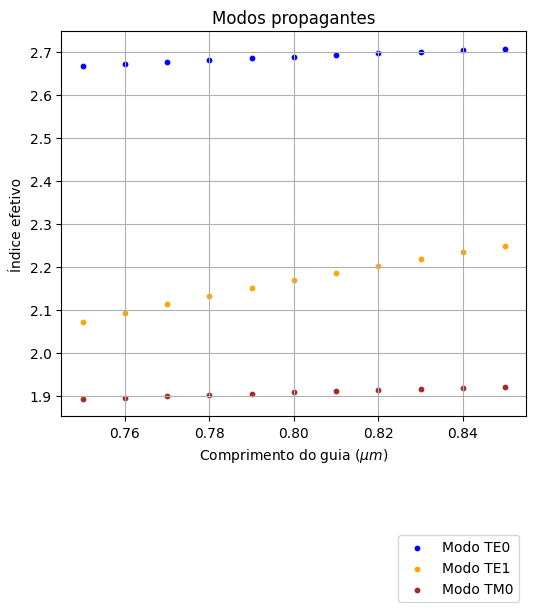

In [24]:
plt.figure(figsize=(6, 5))

lista_cores_TE = ["blue", "orange", "green", "red", "cyan", "yellow", "purple"]
lista_cores_TM = ["brown", "olive", "gray", "lightgreen", "pink", "sandybrown"]

contagemTE = -1
contagemTM = -1

for i in range(len(vec_width2)):
    modoTE = -1
    modoTM = -1
    for j in range(0,num_modos):

        if (matriz_modos2[j, i, 0]) > 1.44: # Condição que exige que o modo seja válido

            if (matriz_modos2[j, i, 1] >= 0.5):
                modoTE = modoTE + 1
                if (contagemTE < modoTE):
                    plt.scatter(vec_width2[i]/microns, matriz_modos2[j, i, 0], color=lista_cores_TE[modoTE], s=10, label='Modo TE%g' % modoTE)
                    contagemTE = contagemTE + 1
                else:
                    plt.scatter(vec_width2[i]/microns, matriz_modos2[j, i, 0], color=lista_cores_TE[modoTE], s=10)
            else:
                modoTM = modoTM + 1
                if (contagemTM < modoTM):
                    plt.scatter(vec_width2[i]/microns, matriz_modos2[j, i, 0], color=lista_cores_TM[modoTM], s=10, label='Modo TM%g' % modoTM)
                    contagemTM = contagemTM + 1
                else:
                    plt.scatter(vec_width2[i]/microns, matriz_modos2[j, i, 0], color=lista_cores_TM[modoTM], s=10)

plt.xlabel('Comprimento do guia ($\mu m$)')
plt.ylabel('Índice efetivo')
plt.title('Modos propagantes')
plt.legend(bbox_to_anchor=(1, -0.5), loc='lower right')
plt.grid(True)

plt.show()

In [30]:
print(matriz_modos1[0, 3, 0])
print(matriz_modos1[0, 4, 0])
print(matriz_modos1[0, 5, 0])

2.1637628518053518
2.196272737013448
2.227032128826454


In [31]:
print(matriz_modos2[1, 6, 0])
print(matriz_modos2[1, 7, 0])
print(matriz_modos2[1, 8, 0])

2.1852314228312975
2.2017982180101705
2.2177440451197294
